In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

from module import make_ff_factors, performance_metrics

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [257]:
KOSPI               = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)
krx_tmi_df          = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)
adj_close_df        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_adj_close.csv', index_col='Date', parse_dates=True)
mkt_cap             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_mkt_cap.csv', index_col='Date', parse_dates=True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)
total_adj_close     = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_adj_close.csv', index_col='Date', parse_dates=True)
trading_value_60    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value_60.csv', index_col='Date', parse_dates=True)
trading_value       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value.csv', index_col='Date', parse_dates=True)

# CPI
inflation           = pd.read_csv('../../00_input/inflation_index.csv', index_col='Date', parse_dates=True)

# 아래는 모두 한 분기 래그 필요
# 연결 (1989-12-31~)
# 값이 12월부터 업데이트
COGS                            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_매출원가.csv', index_col='Date', parse_dates=True)
net_profit                      = pd.read_csv('../../00_input/KOSPI_KOSDAQ_당기순이익.csv', index_col='Date', parse_dates=True)
current_assets                  = pd.read_csv('../../00_input/KOSPI_KOSDAQ_유동자산.csv', index_col='Date', parse_dates=True)
current_liabilities             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_유동부채.csv', index_col='Date', parse_dates=True)
noncurrent_liabilities          = pd.read_csv('../../00_input/KOSPI_KOSDAQ_비유동부채.csv', index_col='Date', parse_dates=True)
short_term_debt                 = pd.read_csv('../../00_input/KOSPI_KOSDAQ_단기차입금.csv', index_col='Date', parse_dates=True)
cash_and_cash_equivalents       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_현금및현금성자산.csv', index_col='Date', parse_dates=True)
retained_earnings               = pd.read_csv('../../00_input/KOSPI_KOSDAQ_이익잉여금.csv', index_col='Date', parse_dates=True)
ebit                            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_EBIT.csv', index_col='Date', parse_dates=True)
net_profit                      = pd.read_csv('../../00_input/KOSPI_KOSDAQ_당기순이익.csv', index_col='Date', parse_dates=True)

# 값이 1월부터 업데이트
gross_profit        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_gross_profit.csv', index_col='Date', parse_dates=True)
cashflow            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_cash_flow.csv', index_col='Date', parse_dates=True)
sales               = pd.read_csv('../../00_input/KOSPI_KOSDAQ_sales.csv', index_col='Date', parse_dates=True)
total_assets        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_asset.csv', index_col='Date', parse_dates=True)
total_liabilities   = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_liabilities.csv', index_col='Date', parse_dates=True)
total_equity        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_equity.csv', index_col='Date', parse_dates=True)
CAPEX               = pd.read_csv('../../00_input/KOSPI_KOSDAQ_CAPEX.csv', index_col='Date', parse_dates=True)
depreciation_exp    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_감가상각비(현금흐름표).csv', index_col='Date', parse_dates=True)

# 분기 (2001-01-31~)
ROE                 = pd.read_csv('../../00_input/KOSPI_KOSDAQ_ROE.csv', index_col='Date', parse_dates=True)
ROA                 = pd.read_csv('../../00_input/KOSPI_KOSDAQ_ROA.csv', index_col='Date', parse_dates=True)

---
##### **데이터 전처리**

In [258]:
# 연결
# 값이 12월부터 업데이트
COGS                            = COGS.shift(15)
net_profit                      = net_profit.shift(15)
current_assets                  = current_assets.shift(15)      
current_liabilities             = current_liabilities.shift(15)
short_term_debt                 = short_term_debt.shift(15)     
cash_and_cash_equivalents       = cash_and_cash_equivalents.shift(15)
retained_earnings               = retained_earnings.shift(15)
ebit                            = ebit.shift(15)
net_profit                      = net_profit.shift(15)

# 값이 1월부터 업데이트
gross_profit        = gross_profit.shift(14)
cashflow            = cashflow.shift(14)
sales               = sales.shift(14)
total_assets        = total_assets.shift(14)
total_liabilities   = total_liabilities.shift(14)
total_equity        = total_equity.shift(14)
CAPEX               = CAPEX.shift(14)
depreciation_exp    = depreciation_exp.shift(14)

# 분기
ROE = ROE.shift(5)
ROA = ROA.shift(5)

Safety 계산

In [259]:
def zscore_by_date(rank_df: pd.DataFrame) -> pd.DataFrame:
    # rank_df: index=Date, columns=기업
    mean = rank_df.mean(axis=1, skipna=True)
    std = rank_df.std(axis=1, skipna=True, ddof=0)  # 모집단 표준편차(ddof=0) 권장
    std_safe = std.where(std != 0)  # std=0이면 NaN 처리
    z = rank_df.sub(mean, axis=0).div(std_safe, axis=0)
    return z

1. BAB

In [260]:
# 일별 로그 수익률 (Log Return)
# r_t = ln(P_t / P_{t-1})
daily_log_ret = np.log(adj_close_df / adj_close_df.shift(1))

# KRX TMI 일별 로그 수익률
krx_tmi_log_ret = np.log(krx_tmi_df / krx_tmi_df.shift(1))

In [261]:
trading_days_1y = 252
min_obs_vol = 120

# 주식별 1년 롤링 변동성
rolling_vol_1y_stocks = daily_log_ret.rolling(
    window=trading_days_1y,
    min_periods=min_obs_vol
).std()

# KRX TMI 1년 롤링 변동성
rolling_vol_1y_tmi = krx_tmi_log_ret.rolling(
    window=trading_days_1y,
    min_periods=min_obs_vol
).std()

In [262]:
corr_window = 252 * 5
min_obs_corr = 750

# KRX TMI가 DataFrame이면 1차원 Series로 변환
krx_tmi_log_ret_series = krx_tmi_log_ret.squeeze()

# 3일 중첩 로그수익률
stock_log_ret_3d = daily_log_ret.rolling(window=3, min_periods=3).sum()
tmi_log_ret_3d = krx_tmi_log_ret_series.rolling(window=3, min_periods=3).sum()

# 주식별 5년 롤링 상관계수
rolling_corr_5y = stock_log_ret_3d.apply(
    lambda col: col.rolling(window=corr_window, min_periods=min_obs_corr).corr(tmi_log_ret_3d)
)

In [263]:
start_date = pd.Timestamp('2013-04-08')

# (1) 공통 인덱스: 세 객체의 날짜(인덱스) 교집합
common_index = rolling_vol_1y_stocks.index
common_index = common_index.intersection(
    getattr(rolling_vol_1y_tmi, 'index', common_index)
)
common_index = common_index.intersection(
    getattr(rolling_corr_5y, 'index', common_index)
)

# (2) 원하는 시작일 이후로 제한
common_index = common_index[common_index >= start_date]

# (3) 각각 공통 인덱스로 슬라이싱/재정렬
rolling_vol_1y_stocks = rolling_vol_1y_stocks.loc[common_index]
rolling_vol_1y_tmi    = rolling_vol_1y_tmi.loc[common_index]
rolling_corr_5y       = rolling_corr_5y.loc[common_index]

In [264]:
# KRX TMI 변동성을 1차원 Series로 변환
rolling_vol_1y_tmi_series = rolling_vol_1y_tmi.squeeze()

# 0 방지
rolling_vol_1y_tmi_series = rolling_vol_1y_tmi_series.replace(0, np.nan)

# TS beta 계산
beta_ts = rolling_corr_5y.mul(rolling_vol_1y_stocks, axis=0).div(rolling_vol_1y_tmi_series, axis=0)

In [265]:
# =========================
# Ex Ante Beta 계산
# beta_ex_ante = 0.6 * beta_ts + 0.4 * 1
# =========================

shrink_w = 0.6
beta_xs = 1.0

ex_ante_beta = shrink_w * beta_ts + (1 - shrink_w) * beta_xs
BAB = -ex_ante_beta

2. LEV 

In [266]:
# leverage: 낮을수록 안전하므로 음수 부호
LEV = - total_liabilities / total_assets

# 이상치 처리
LEV = LEV.replace([np.inf, -np.inf], np.nan)

# rank -> z-score
LEV_rank = LEV.rank(axis=1, ascending=False, method='first', na_option='keep').astype('Int64')
LEV_z = zscore_by_date(LEV_rank.astype(float))

3. Ohlson O-score

In [267]:
# 공통 정렬 함수
def align_panel(base, others):
    common_index = base.index
    common_columns = base.columns
    for df in others:
        common_index = common_index.intersection(df.index)
        common_columns = common_columns.intersection(df.columns)
    aligned = [df.loc[common_index, common_columns] for df in [base] + others]
    return aligned

(
    total_assets,
    total_liabilities,
    current_assets,
    current_liabilities,
    net_profit,
    ebit,
    mkt_cap
) = align_panel(
    total_assets,
    [total_liabilities, current_assets, current_liabilities, net_profit, ebit, mkt_cap]
)


In [268]:
# CPI 준비
# inflation_index.csv에 'CPI' 컬럼이 있다고 가정
cpi = inflation['CPI'].resample('ME').last()
cpi = cpi.reindex(total_assets.index).ffill()

cpi_panel = pd.DataFrame(
    np.repeat(cpi.values[:, None], total_assets.shape[1], axis=1),
    index=total_assets.index,
    columns=total_assets.columns
)

# Adjusted assets
adjasset = total_assets + 0.1 * (mkt_cap - total_equity)

# O-score 구성항목
TLTA = total_liabilities / adjasset
WCTA = (current_assets - current_liabilities) / adjasset
CLCA = current_liabilities / current_assets
OENEG = (total_liabilities > total_assets).astype(float)
NITA = net_profit / total_assets
FUTL = ebit / total_liabilities
INTWO = ((net_profit < 0) & (net_profit.shift(12) < 0)).astype(float)
CHIN = (net_profit - net_profit.shift(12)) / (net_profit.abs() + net_profit.shift(12).abs())

# 이상치/0분모 처리
TLTA = TLTA.replace([np.inf, -np.inf], np.nan)
WCTA = WCTA.replace([np.inf, -np.inf], np.nan)
CLCA = CLCA.replace([np.inf, -np.inf], np.nan)
NITA = NITA.replace([np.inf, -np.inf], np.nan)
FUTL = FUTL.replace([np.inf, -np.inf], np.nan)
CHIN = CHIN.replace([np.inf, -np.inf], np.nan)

# O-score
O_score = (
    -1.32
    - 0.407 * np.log(adjasset / cpi_panel)
    + 6.03 * TLTA
    - 1.43 * WCTA
    + 0.076 * CLCA
    - 1.72 * OENEG
    - 2.37 * NITA
    - 1.83 * FUTL
    + 0.285 * INTWO
    - 0.521 * CHIN
)

# Safety용 방향 반전: 낮은 O-score가 더 안전
O_safe = -O_score

4. Z

In [269]:
# Working capital
Z_WC = current_assets - current_liabilities

# Altman Z-score
Z = (
    1.2 * Z_WC
    + 1.4 * retained_earnings
    + 3.3 * ebit
    + 0.6 * mkt_cap
    + sales
) / total_assets

5. EVOL

In [270]:
# 같은 값이 반복되는 월들을 제거하고, 실제 분기 갱신 시점만 남김
ROE_q = ROE.where(ROE.ne(ROE.shift(1)))
ROE_q = ROE_q.dropna(how='all')

# 과거 60개 분기 기준 표준편차
# 논문: 최소 12 non-missing quarters 필요
EVOL_q = ROE_q.rolling(window=60, min_periods=12).std()

# 월말 패널로 다시 확장, 2004-03-31부터만 데이터 있음
month_ends = ROE.index
EVOL = EVOL_q.reindex(month_ends).ffill()

In [271]:
# 각 지표가 실제로 처음 유효해지는 날짜 확인
factor_map = {
    "BAB": BAB,
    "LEV": LEV,
    "O_safe": O_safe,
    "Z": Z,
    "EVOL": EVOL,
}

start_summary = pd.Series({
    name: df.dropna(how="all").index.min()
    for name, df in factor_map.items()
}).sort_values()

print(start_summary)

LEV      1991-02-28
Z        1991-03-31
O_safe   1993-06-30
EVOL     2004-01-31
BAB      2013-04-08
dtype: datetime64[ns]


z-score

In [272]:
def zscore_by_date(rank_df: pd.DataFrame) -> pd.DataFrame:
    # rank_df: index=Date, columns=기업
    mean = rank_df.mean(axis=1, skipna=True)
    std = rank_df.std(axis=1, skipna=True, ddof=0)  # 모집단 표준편차(ddof=0) 권장
    std_safe = std.where(std != 0)  # std=0이면 NaN 처리
    z = rank_df.sub(mean, axis=0).div(std_safe, axis=0)
    return z

In [273]:
# 1. 각 지표 rank -> z-score
BAB_rank  = BAB.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
LEV_rank  = LEV.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
O_rank    = O_safe.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
Z_rank    = Z.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")

# EVOL은 낮을수록 안전하므로 부호 반전 후 rank
EVOL_safe = -EVOL
EVOL_rank = EVOL_safe.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")

BAB_z  = zscore_by_date(BAB_rank.astype(float))
LEV_z  = zscore_by_date(LEV_rank.astype(float))
O_z    = zscore_by_date(O_rank.astype(float))
Z_z    = zscore_by_date(Z_rank.astype(float))
EVOL_z = zscore_by_date(EVOL_rank.astype(float))

# 2. 공통 시작 시점 확인
z_map = {
    "BAB": BAB_z,
    "LEV": LEV_z,
    "O": O_z,
    "Z": Z_z,
    "EVOL": EVOL_z,
}

common_start = max(
    df.dropna(how="all").index.min()
    for df in z_map.values()
)

print("Common start:", common_start)

# 3. 공통 시작 시점 이후로 정렬
BAB_z_aligned  = BAB_z.loc[common_start:]
LEV_z_aligned  = LEV_z.loc[common_start:]
O_z_aligned    = O_z.loc[common_start:]
Z_z_aligned    = Z_z.loc[common_start:]
EVOL_z_aligned = EVOL_z.loc[common_start:]

Common start: 2013-04-08 00:00:00


In [274]:
# 5. 논문식: available한 값만 평균
safety_v1 = pd.concat(
    [BAB_z_aligned, LEV_z_aligned, O_z_aligned, Z_z_aligned, EVOL_z_aligned],
    keys=["BAB", "LEV", "O", "Z", "EVOL"]
).groupby(level=1).mean()

In [275]:
# 낮을수록 좋은 지표
safety_v1 = safety_v1.resample('ME').last()

In [276]:
out_path = Path(r"C:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input\safety_v1.csv")
safety_v1.to_csv(out_path, encoding="utf-8-sig", index_label="Date")

In [277]:
factor_df = safety_v1

In [278]:
# 월간 데이터 계산
monthly_rets      = total_adj_close.resample('ME').last().pct_change(fill_method=None)

# 수익률 윈저라이징
monthly_rets_wins = monthly_rets.clip(
    lower=monthly_rets.quantile(0.01),
    upper=monthly_rets.quantile(0.99),
    axis=1
)

In [279]:
# 일별 수익률과 거래대금을 이용해 Amihud illiquidity 계산
daily_ret        = adj_close_df.pct_change(fill_method=None)
daily_illiq      = (daily_ret.abs()/trading_value)
illiq            = daily_illiq.resample('ME').mean()

---
##### **리밸런싱 날짜 설정**

In [280]:
# 백테스트 기간을 설정하여 월말 날짜 리스트 생성
start_point = '2013-04-30'
end_point   = '2026-02-28'

month_ends  = pd.date_range(start=start_point, end=end_point, freq='ME')

In [301]:
# 종목 수 선정
n                      = 20  

# 가중방식 선택
weight_method_temp     = "Equal"  # ['Equal'(동일가중), Cap'(시가총액가중)]

# 유동성 하위 종목 제외
trading_threshold      = 0.10     # 유동성 하위 종목 제외

# 거래대금 설정
high_cost              = 0.008    # 80bp
low_cost               = 0.003    # 30bp
illiq_threshold        = 0.80     # Amihud 유동성 기준 상위 20%

portfolio_return       = pd.Series(dtype=float)
total_trade            = pd.Series(dtype=float)

initial_NAV            = 1        # 초기값
NAV                    = initial_NAV

---
##### **전체 기간 포트폴리오 수익률 계산**

In [302]:
portfolio_return = pd.Series(index=month_ends, dtype=float)
total_trade      = pd.Series(index=month_ends, dtype=float)
prev_portfolio   = pd.Series(dtype=float)

portfolio_return[month_ends[0]] = 0.0
NAV = initial_NAV

In [303]:
# for i in range(len(month_ends) - 1):

#     # 매기간 날짜 업데이트
#     start_date  = month_ends[i]
#     end_date    = month_ends[i + 1]

#     # 거래대금 하위 종목 제외
#     trading_today      = trading_value_60.loc[start_date].dropna()
#     filtered           = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

#     factor_filtered    = factor_df.loc[start_date, filtered].dropna()

#     # 종목 선정
#     basket = factor_filtered.nsmallest(n).index

#     # 유동성 반영
#     illiq_startdate = illiq.loc[start_date].dropna()
#     threshold       = illiq_startdate.quantile(illiq_threshold)
#     illiquid_top20  = illiq_startdate[illiq_startdate >= threshold].index

#     # 가중방식 선택
#     prev_weights   = prev_portfolio / prev_portfolio.sum()
    
#     # 동일가중
#     if weight_method_temp == 'Equal':
#         target_weights = pd.Series(1.0/len(basket), index=basket)

#     # 시가총액가중
#     else:
#         cap = mkt_cap.loc[start_date, basket]
#         target_weights = cap/cap.sum()

#     # 거래비용 반영
#     all_index = target_weights.index.union(prev_weights.index)
#     target_w = target_weights.reindex(all_index, fill_value=0)
#     prev_w   = prev_weights.reindex(all_index, fill_value=0)

#     delta_w   = target_w - prev_w
#     trade_amounts = abs(delta_w) * NAV
#     cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

#     trade_cost = (trade_amounts * cost_rate).sum()

#     NAV_new = NAV - trade_cost
    
#     current_portfolio_value = target_weights * NAV_new

#     # 당기 포트폴리오 최종 가치 계산
#     ret_seg              = monthly_rets_wins.loc[end_date, basket]
#     next_portfolio_value = current_portfolio_value * (ret_seg + 1)

#     # 당기 포트폴리오 수익률 계산
#     NAV_new       = next_portfolio_value.sum()
#     portfolio_ret = NAV_new / NAV - 1

#     # prev_portfolio 업데이트
#     prev_portfolio = next_portfolio_value

#     # NAV 업데이트
#     NAV = NAV_new

#     # 총 거래금액 저장
#     total_trade.loc[start_date] = trade_amounts.sum()
    
#     # 포트폴리오 수익률 저장
#     portfolio_return.loc[end_date] = portfolio_ret

In [304]:
mkt_cap             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_mkt_cap.csv', index_col='Date', parse_dates=True)

In [305]:
pct = 0.2

for i in range(len(month_ends) - 1):

    # 매기간 날짜 업데이트
    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    # 거래대금 하위 종목 제외
    trading_today = trading_value_60.loc[start_date].dropna()
    filtered = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

    factor_filtered = factor_df.loc[start_date, filtered].dropna()

    # 종목 선정: factor 하위 20%
    if factor_filtered.empty:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = 0.0
        continue

    n_select = max(1, int(np.ceil(len(factor_filtered) * pct)))
    basket = factor_filtered.nlargest(n_select).index

    # 유동성 반영
    illiq_startdate = illiq.loc[start_date].dropna()
    threshold = illiq_startdate.quantile(illiq_threshold)
    illiquid_top20 = illiq_startdate[illiq_startdate >= threshold].index

    # 가중방식 선택
    prev_weights = prev_portfolio / prev_portfolio.sum() if prev_portfolio.sum() != 0 else pd.Series(dtype=float)

    # 동일 가중
    if weight_method_temp == 'Equal':
        target_weights = pd.Series(1.0 / len(basket), index=basket)

    # 시가 총액 가중
    else:
        cap = mkt_cap.loc[start_date, basket].dropna()
        target_weights = cap / cap.sum()
        basket = target_weights.index  # 결측 cap 제거 반영

    # 거래비용 반영
    all_index = target_weights.index.union(prev_weights.index)
    target_w = target_weights.reindex(all_index, fill_value=0)
    prev_w = prev_weights.reindex(all_index, fill_value=0)

    delta_w = target_w - prev_w
    trade_amounts = abs(delta_w) * NAV
    cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

    trade_cost = (trade_amounts * cost_rate).sum()

    NAV_new = NAV - trade_cost
    current_portfolio_value = target_weights * NAV_new

    # 당기 포트폴리오 최종 가치 계산
    ret_seg = monthly_rets_wins.loc[end_date, basket].dropna()
    common = current_portfolio_value.index.intersection(ret_seg.index)
    # print(end_date, common)
    if len(common) == 0:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = trade_amounts.sum()
        continue

    next_portfolio_value = current_portfolio_value.loc[common] * (ret_seg.loc[common] + 1)

    # 당기 포트폴리오 수익률 계산
    NAV_new = next_portfolio_value.sum()
    portfolio_ret = NAV_new / NAV - 1

    # prev_portfolio 업데이트
    prev_portfolio = next_portfolio_value

    # NAV 업데이트
    NAV = NAV_new

    # 총 거래금액 저장
    total_trade.loc[start_date] = trade_amounts.sum()

    # 포트폴리오 수익률 저장
    portfolio_return.loc[end_date] = portfolio_ret


In [306]:
portfolio_return.tail()

2025-10-31    0.038463
2025-11-30   -0.019203
2025-12-31    0.025112
2026-01-31    0.121339
2026-02-28    0.034821
Freq: ME, dtype: float64

---
##### **NAV 계산 및 OUTPUT 데이터 전처리**

In [307]:
portfolio_NAV = (1 + portfolio_return).cumprod() * initial_NAV

In [308]:
# Portfolio 데이터 생성
df = pd.concat(
    [portfolio_return, portfolio_NAV, total_trade], 
    axis=1
)

df.columns = ["Return", "NAV", "Trade"]
df.index.name = "Date"

# 초기값 저장
df.loc[df.index[0], "NAV"] = initial_NAV

portfolio = df

---
### **1. 수익률 분석**

포트폴리오 초과수익률 = 상수 + 시장 초과수익률 + SMB + HML + MOM + 잔차

In [309]:
factors_monthly = make_ff_factors(factors)[:-1]

In [310]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([df['Return'], factors_monthly], axis=1, join="inner").dropna()

In [311]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

In [312]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     278.1
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.75e-68
Time:                        23:54:24   Log-Likelihood:                 412.14
No. Observations:                 155   AIC:                            -814.3
Df Residuals:                     150   BIC:                            -799.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0039      0.001     -3.443      0.0

---
### **2. 성과지표 계산**

In [313]:
metrics = performance_metrics(portfolio)

In [314]:
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

CAGR: 0.0180
Volatility (ann.): 0.2146
Sharpe Ratio: 0.1917
MDD: -0.4730
Average Turnover (monthly): 0.4738


---
**NAV Plot**

In [315]:
df_ret = pd.concat([portfolio['Return'].dropna(), factors_monthly['KOSPI']], axis=1, join='inner')
df_ret.columns = ['Portfolio', 'KOSPI']
df_ret.index.name = 'Date'

In [316]:
df_nav = (1 + df_ret).cumprod()
df_nav.columns = ['Portfolio', 'KOSPI']

In [317]:
df_nav

,Portfolio,KOSPI
Date,,
2013-04-30,1.000000,0.979580
2013-05-31,1.050083,0.998085
2013-06-30,0.921859,0.929388
2013-07-31,0.977289,0.954681
2013-08-31,0.910165,0.960831
...,...,...
2025-10-31,1.078236,2.048741
2025-11-30,1.057531,1.958506
2025-12-31,1.084088,2.101946


<Axes: xlabel='Date'>

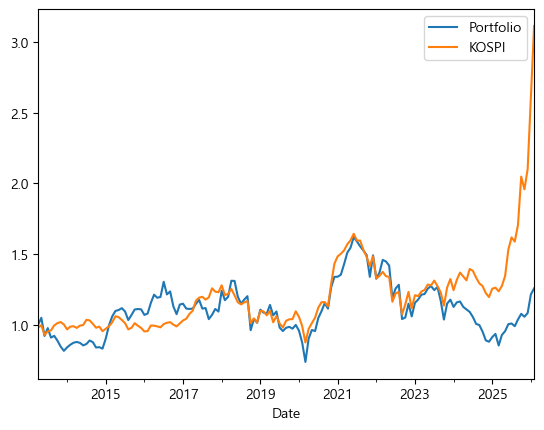

In [318]:
df_nav.plot()

---
**로그누적수익률 Plot**

<Axes: xlabel='Date'>

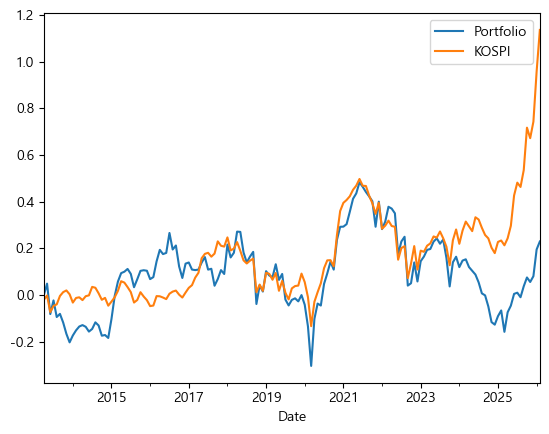

In [319]:
np.log1p(df_ret).cumsum().plot()